In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.9 MB/s eta 0:00:00


In [ ]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import os
import cv2
from pathlib import Path
from PIL import Image
import zipfile
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sys
import random

In [ ]:
DRIVE_ROOT = Path("/content/drive/MyDrive/Fall 2025/ML/Final")
SPLIT_DIR = DRIVE_ROOT / "train_val_split"
CHECKPOINT_DIR = DRIVE_ROOT / "checkpoints"

TRAIN_ZIP = SPLIT_DIR / "train_512.zip"
VAL_ZIP = SPLIT_DIR / "val_512.zip"
TRAIN_CSV_PATH = SPLIT_DIR / "bboxes_train.csv"
VAL_CSV_PATH = SPLIT_DIR / "bboxes_val.csv"

LOCAL_TRAIN_DIR = Path("/content/train_512")
LOCAL_VAL_DIR = Path("/content/val_512")

In [ ]:
def unzip_data(zip_path, dest_dir):
    if not dest_dir.exists():
        print(f"Extracting {zip_path.name} to {dest_dir}...")
        dest_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dest_dir)
        print("Done.")
    else:
        print(f"{dest_dir.name} already extracted.")

In [ ]:
class RSNADetectionDataset(Dataset):
    def __init__(self, img_dir, csv_file, transforms=None):
        self.img_dir = Path(img_dir)
        self.transforms = transforms

        image_files = list(self.img_dir.rglob("*.png")) + list(self.img_dir.rglob("*.jpg"))
        if len(image_files) == 0:
            raise RuntimeError(f"No bueno")

        self.patient_ids = [f.stem for f in image_files]
        self.patient_map = {f.stem: f for f in image_files}

        df = pd.read_csv(csv_file)

        self.df = df[df['patientId'].isin(self.patient_ids)].copy()
        self.grouped = self.df.groupby('patientId')

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, idx):
        patient_id = self.patient_ids[idx]
        img_path = self.patient_map[patient_id]

        image = Image.open(img_path).convert("RGB")
        image = np.array(image) / 255.0
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float()

        boxes = []
        labels = []

        if patient_id in self.grouped.groups:
            group = self.grouped.get_group(patient_id)
            for _, row in group.iterrows():
                try:
                    x_min = float(row['x_min'])
                    y_min = float(row['y_min'])
                    x_max = float(row['x_max'])
                    y_max = float(row['y_max'])

                    # Sanity check
                    if x_max > x_min and y_max > y_min:
                        boxes.append([x_min, y_min, x_max, y_max])
                        labels.append(1) # Pneumonia
                except KeyError:
                    try:
                        if 'Target' in row and row['Target'] == 0:
                            continue

                        x_min = float(row['x'])
                        y_min = float(row['y'])
                        x_max = float(row['x']) + float(row['width'])
                        y_max = float(row['y']) + float(row['height'])
                        boxes.append([x_min, y_min, x_max, y_max])
                        labels.append(1)
                    except KeyError:
                        pass

        target = {}
        target["image_id"] = torch.tensor([idx])

        if len(boxes) > 0:
            target["boxes"] = torch.as_tensor(boxes, dtype=torch.float32)
            target["labels"] = torch.as_tensor(labels, dtype=torch.int64)
        else:
            target["boxes"] = torch.zeros((0, 4), dtype=torch.float32)
            target["labels"] = torch.zeros((0,), dtype=torch.int64)

        return image_tensor, target

In [ ]:
def get_faster_rcnn(num_classes=2):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def collate_fn(batch):
    return tuple(zip(*batch))

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

Extracting train_512.zip to /content/train_512...
Done.
Extracting val_512.zip to /content/val_512...
Done.

--- Initializing Datasets ---
Loading CSV from bboxes_train.csv...
Loading CSV from bboxes_val.csv...

--- DEBUG: Verifying Dataset Labels ---
Found positive sample at index 6. Plotting...


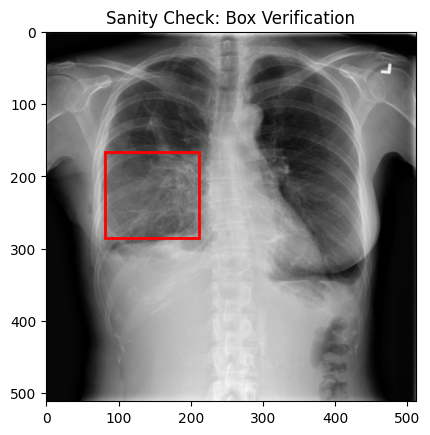

Dataset verification passed.
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 188MB/s]


No checkpoint found. Starting from scratch.

--- Starting Training ---


Epoch 1: 100%|██████████| 6404/6404 [12:05<00:00,  8.83it/s, loss=0.135]


Epoch 1 | Train Loss: 0.0789 | Val Loss: 0.0821
Checkpoint saved.


...

Epoch 8 | Train Loss: 0.0693 | Val Loss: 0.0729
Checkpoint saved.


Epoch 9: 100%|██████████| 6404/6404 [12:17<00:00,  8.68it/s, loss=0.0916]


Epoch 9 | Train Loss: 0.0693 | Val Loss: 0.0726
Checkpoint saved.


Epoch 10: 100%|██████████| 6404/6404 [12:13<00:00,  8.73it/s, loss=0.25]


Epoch 10 | Train Loss: 0.0689 | Val Loss: 0.0727
Checkpoint saved.
Training Complete.


In [ ]:
if __name__ == "__main__":
    unzip_data(TRAIN_ZIP, LOCAL_TRAIN_DIR)
    unzip_data(VAL_ZIP, LOCAL_VAL_DIR)

    train_ds = RSNADetectionDataset(LOCAL_TRAIN_DIR, TRAIN_CSV_PATH)
    val_ds = RSNADetectionDataset(LOCAL_VAL_DIR, VAL_CSV_PATH)

    # Sanity check
    positive_count = 0
    for i in range(min(500, len(train_ds))):
        _, t = train_ds[i]
        if len(t['boxes']) > 0:
            positive_count += 1
            print(f"Found positive sample at index {i}. Plotting...")
            img, target = train_ds[i]
            img_np = img.permute(1, 2, 0).numpy()

            fig, ax = plt.subplots(1)
            ax.imshow(img_np)
            for box in target['boxes']:
                x1, y1, x2, y2 = box.numpy()
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
                ax.add_patch(rect)
            plt.title("Sanity check to make sure boxes are actually found")
            plt.show()
            break

    if positive_count == 0:
        print("No bueno, no boxes")
        sys.exit(1)
    else:
        print("Bueno")

    train_dl = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2, collate_fn=collate_fn)
    val_dl = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)

    model = get_faster_rcnn(num_classes=2)
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    CHECKPOINT_PATH = CHECKPOINT_DIR / "fasterrcnn_resume.pth"
    start_epoch = 0

    if CHECKPOINT_PATH.exists():
        print(f"\nFound checkpoint at {CHECKPOINT_PATH}. Resuming...")
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        lr_scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming from Epoch {start_epoch}")
    else:
        print("No checkpoint found. Starting from scratch.")

    def train_one_epoch(model, optimizer, loader, device, epoch):
        model.train()
        running_loss = 0.0
        loop = tqdm(loader, desc=f"Epoch {epoch+1}")

        for images, targets in loop:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            loss_value = losses.item()

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            running_loss += loss_value
            loop.set_postfix(loss=loss_value)

        return running_loss / len(loader)

    def evaluate_loss(model, loader, device):
        model.train()
        running_loss = 0.0
        with torch.no_grad():
            for images, targets in loader:
                images = list(image.to(device) for image in images)
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
                running_loss += losses.item()
        return running_loss / len(loader)

    EPOCHS = 10

    for epoch in range(start_epoch, EPOCHS):
        train_loss = train_one_epoch(model, optimizer, train_dl, device, epoch)
        lr_scheduler.step()

        val_loss = evaluate_loss(model, val_dl, device)
        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': lr_scheduler.state_dict(),
            'loss': train_loss,
        }, CHECKPOINT_PATH)
        print("Checkpoint saved.")

    print("Training Complete.")

Searching for a positive validation case to visualize...


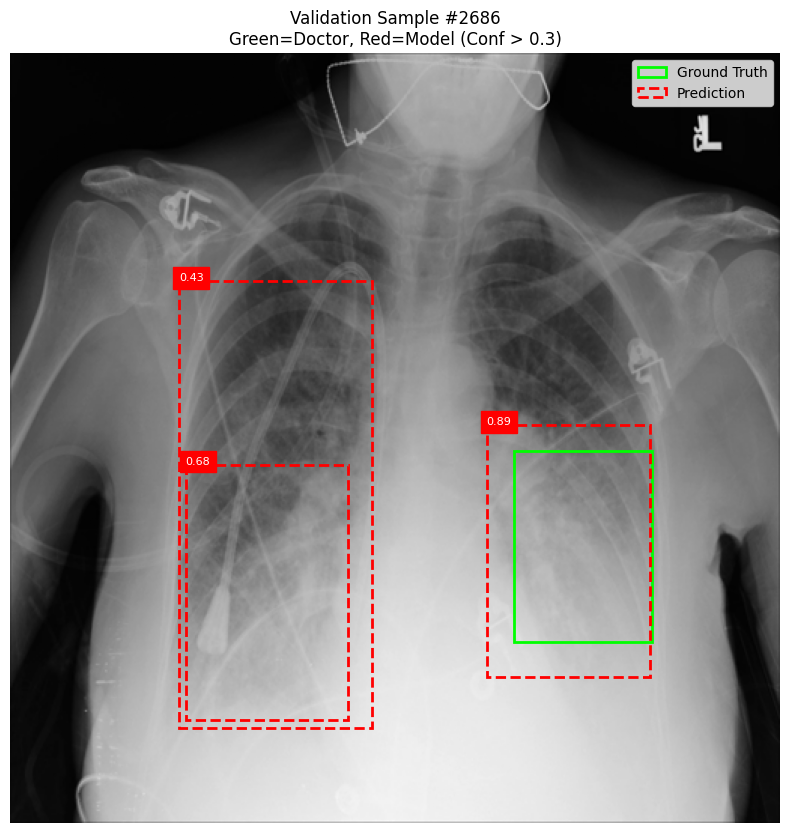

In [ ]:
model.eval()

max_retries = 20
found_positive = False

for _ in range(max_retries):
    idx = random.randint(0, len(val_ds)-1)
    img, target = val_ds[idx]

    # Check if the ground truth actually has boxes
    if len(target['boxes']) > 0:
        found_positive = True
        break

if not found_positive:
    print("Could not find a positive case")

with torch.no_grad():
    prediction = model([img.to(device)])[0]

img_np = img.permute(1, 2, 0).cpu().numpy()

# Ground truth
gt_boxes = target['boxes'].numpy()

# Predicted
pred_boxes = prediction['boxes'].cpu().numpy()
pred_scores = prediction['scores'].cpu().numpy()

confidence_threshold = 0.3
keep = pred_scores > confidence_threshold

In [ ]:
fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(img_np)

# Ground truth green
for box in gt_boxes:
    x1, y1, x2, y2 = box
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='lime', facecolor='none', label='Ground Truth')
    ax.add_patch(rect)

# Predictions red
for box, score in zip(pred_boxes[keep], pred_scores[keep]):
    x1, y1, x2, y2 = box
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none', linestyle='--', label='Prediction')
    ax.add_patch(rect)
    ax.text(x1, y1, f"{score:.2f}", color='white', fontsize=8, backgroundcolor='red')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

plt.title(f"Validation Sample #{idx}\nGreen=Doctor, Red=Model (Conf > {confidence_threshold})")
plt.axis('off')
plt.show()

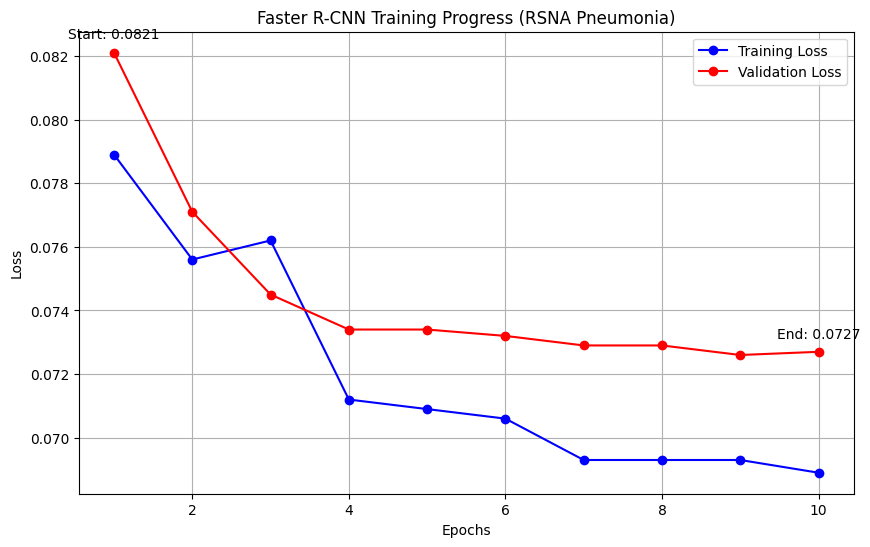

In [ ]:
epochs = range(1, 11)
train_loss = [0.0789, 0.0756, 0.0762, 0.0712, 0.0709, 0.0706, 0.0693, 0.0693, 0.0693, 0.0689]
val_loss =   [0.0821, 0.0771, 0.0745, 0.0734, 0.0734, 0.0732, 0.0729, 0.0729, 0.0726, 0.0727]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')

plt.title('Faster R-CNN Training Progress (RSNA Pneumonia)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.annotate(f'Start: {val_loss[0]}', (1, val_loss[0]), textcoords="offset points", xytext=(0,10), ha='center')
plt.annotate(f'End: {val_loss[-1]}', (10, val_loss[-1]), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

In [ ]:
def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

def evaluate_model(model, loader, device, iou_threshold=0.5, conf_threshold=0.5):
    model.eval()

    true_positives = 0
    false_positives = 0
    false_negatives = 0

    with torch.no_grad():
        for images, targets in tqdm(loader):
            images = list(image.to(device) for image in images)

            outputs = model(images)

            for i, output in enumerate(outputs):
                pred_boxes = output['boxes'].cpu().numpy()
                pred_scores = output['scores'].cpu().numpy()
                gt_boxes = targets[i]['boxes'].cpu().numpy()

                keep = pred_scores > conf_threshold
                pred_boxes = pred_boxes[keep]

                if len(gt_boxes) == 0:
                    false_positives += len(pred_boxes)
                    continue

                if len(pred_boxes) == 0:
                    false_negatives += len(gt_boxes)
                    continue

                matched_gt = set()

                for p_box in pred_boxes:
                    best_iou = 0
                    best_gt_idx = -1

                    for g_idx, g_box in enumerate(gt_boxes):
                        iou = calculate_iou(p_box, g_box)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = g_idx

                    if best_iou >= iou_threshold and best_gt_idx not in matched_gt:
                        true_positives += 1
                        matched_gt.add(best_gt_idx)
                    else:
                        false_positives += 1

                false_negatives += len(gt_boxes) - len(matched_gt)

    epsilon = 1e-6
    precision = true_positives / (true_positives + false_positives + epsilon)
    recall = true_positives / (true_positives + false_negatives + epsilon)
    f1_score = 2 * (precision * recall) / (precision + recall + epsilon)

    print("\n--- Final Model Performance ---")
    print(f"Confidence Threshold: {conf_threshold}")
    print(f"IoU Threshold: {iou_threshold}")
    print(f"Precision: {precision:.4f} (When it predicts pneumonia, how often is it right?)")
    print(f"Recall:    {recall:.4f} (Out of all real pneumonia cases, how many did it find?)")
    print(f"F1-Score:  {f1_score:.4f} (Balance between Precision and Recall)")

    return precision, recall, f1_score

evaluate_model(model, val_dl, device)

Calculating metrics on Validation Set...


100%|██████████| 1602/1602 [01:46<00:00, 14.98it/s]


--- Final Model Performance ---
Confidence Threshold: 0.5
IoU Threshold: 0.5
Precision: 0.3320 (When it predicts pneumonia, how often is it right?)
Recall:    0.6372 (Out of all real pneumonia cases, how many did it find?)
F1-Score:  0.4366 (Balance between Precision and Recall)


(0.33203483035471243, 0.6372031659467005, 0.4365768317493561)

Running Full Evaluation (IoU Threshold=0.5)...


100%|██████████| 1602/1602 [01:46<00:00, 15.06it/s]
/tmp/ipython-input-807510720.py:123: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precisions, recalls) # Simple approximation



--- FINAL METRICS ---
Total Ground Truth Boxes: 2274
Total Predictions: 20888
Average Precision (AP) @ IoU=0.5: 0.4154


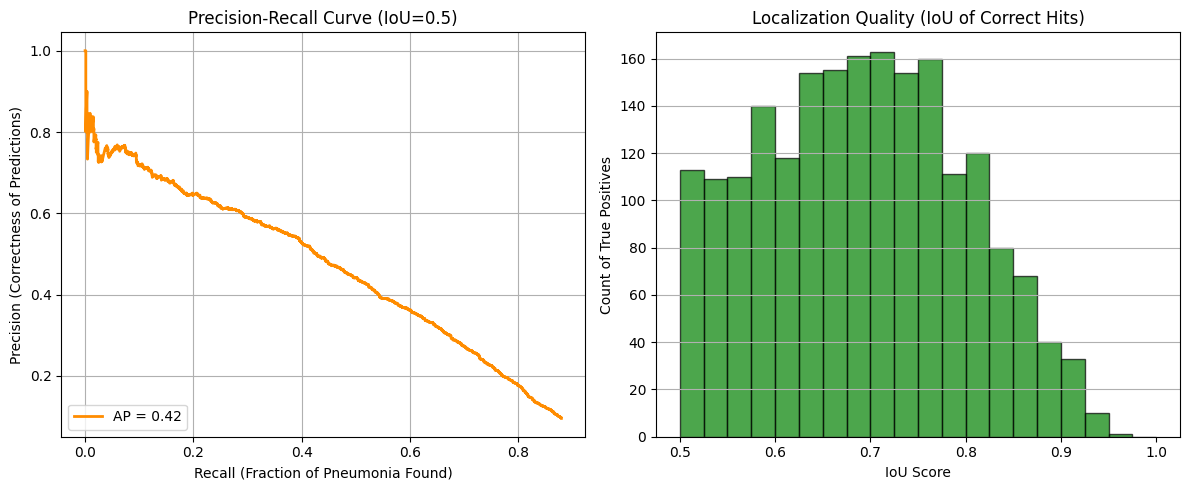

(np.float64(0.41537791757706743),
 array([0.999999  , 0.9999995 , 0.99999967, ..., 0.09575792, 0.09575334,
        0.09574876]),
 array([4.39753738e-04, 8.79507475e-04, 1.31926121e-03, ...,
        8.79507475e-01, 8.79507475e-01, 8.79507475e-01]))

In [ ]:
def calculate_iou(boxA, boxB):
    # box: [x1, y1, x2, y2]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

def evaluate_model(model, loader, device, iou_threshold=0.5):
    model.eval()

    all_predictions = []

    total_ground_truth_boxes = 0
    tp_iou_values = []

    with torch.no_grad():
        for images, targets in tqdm(loader):
            images = list(image.to(device) for image in images)

            outputs = model(images)

            for i, output in enumerate(outputs):
                pred_boxes = output['boxes'].cpu().numpy()
                pred_scores = output['scores'].cpu().numpy()
                gt_boxes = targets[i]['boxes'].cpu().numpy()

                total_ground_truth_boxes += len(gt_boxes)

                if len(pred_boxes) == 0:
                    continue

                if len(gt_boxes) == 0:
                    for score in pred_scores:
                        all_predictions.append([score, 0, 0.0])
                    continue

                matched_gt_indices = set()
                sorted_idxs = np.argsort(-pred_scores)
                pred_boxes = pred_boxes[sorted_idxs]
                pred_scores = pred_scores[sorted_idxs]

                for p_idx, p_box in enumerate(pred_boxes):
                    score = pred_scores[p_idx]
                    best_iou = 0
                    best_gt_idx = -1

                    for g_idx, g_box in enumerate(gt_boxes):
                        iou = calculate_iou(p_box, g_box)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = g_idx

                    if best_iou >= iou_threshold:
                        if best_gt_idx not in matched_gt_indices:
                            all_predictions.append([score, 1, best_iou])
                            matched_gt_indices.add(best_gt_idx)
                            tp_iou_values.append(best_iou)
                        else:
                            all_predictions.append([score, 0, best_iou])
                    else:
                        all_predictions.append([score, 0, best_iou])


    all_predictions = np.array(all_predictions)

    sort_indices = np.argsort(-all_predictions[:, 0])
    all_predictions = all_predictions[sort_indices]

    tps = all_predictions[:, 1]
    fps = 1 - tps

    tp_cumsum = np.cumsum(tps)
    fp_cumsum = np.cumsum(fps)

    precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)

    recalls = tp_cumsum / (total_ground_truth_boxes + 1e-6)

    ap = np.trapz(precisions, recalls)

    print(f"Total Ground Truth Boxes: {total_ground_truth_boxes}")
    print(f"Total Predictions: {len(all_predictions)}")
    print(f"Average Precision (AP) @ IoU={iou_threshold}: {ap:.4f}")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(recalls, precisions, color='darkorange', lw=2, label=f'AP = {ap:.2f}')
    plt.xlabel('Recall (Fraction of Pneumonia Found)')
    plt.ylabel('Precision (Correctness of Predictions)')
    plt.title(f'Precision-Recall Curve (IoU={iou_threshold})')
    plt.legend(loc="lower left")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.hist(tp_iou_values, bins=20, range=(0.5, 1.0), color='green', edgecolor='black', alpha=0.7)
    plt.xlabel('IoU Score')
    plt.ylabel('Count of True Positives')
    plt.title('Localization Quality (IoU of Correct Hits)')
    plt.grid(axis='y')

    plt.tight_layout()
    plt.show()

    return ap, precisions, recalls

evaluate_model(model, val_dl, device)